In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import os
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score
from sklearn import metrics 

import warnings
warnings.filterwarnings('ignore')

## **Scaller Funcations**

In [2]:
from sklearn.preprocessing import StandardScaler,RobustScaler
sc = StandardScaler()
rb = RobustScaler()

### **Reading the Data**

In [3]:
train = pd.read_csv('../input/shai-music-genre-classification/train (1).csv')
test = pd.read_csv("../input/shai-music-genre-classification/test (2).csv")

#targets = tf.keras.utils.to_categorical(train['Class'], num_classes=11, dtype='float32')
targets = train['Class']

#### **Checking for Null Value**

In [4]:
train.isna().sum()

Id                       0
Artist Name              0
Track Name               0
Popularity             333
danceability             0
energy                   0
key                   1609
loudness                 0
mode                     0
speechiness              0
acousticness             0
instrumentalness      3541
liveness                 0
valence                  0
tempo                    0
duration_in min/ms       0
time_signature           0
Class                    0
dtype: int64

# **Data Visualization**

In [5]:
train['Class'].value_counts()

10    3959
6     2069
9     2019
8     1483
5     1157
1     1098
2     1018
0      500
7      461
3      322
4      310
Name: Class, dtype: int64

In [6]:
train

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.1060,0.235,152.429,204947.000000,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.046800,0.1040,0.380,132.921,191956.000000,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.635000,0.2840,0.635,159.953,161037.000000,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.021300,0.3000,0.501,172.472,298093.000000,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.2110,0.619,88.311,254145.000000,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14391,14392,NOISY,I Wish I Was A...,47.0,0.607,0.946,1.0,-2.965,1,0.1500,0.005480,0.000390,0.2780,0.653,120.011,195181.000000,4,10
14392,14393,BLOODSPOT,Deadline Story (feat. Patrick Boos),27.0,0.435,0.951,8.0,-7.475,1,0.0576,0.000005,0.550000,0.0952,0.203,135.034,282043.000000,4,8
14393,14394,Cold Years,Too Far Gone,22.0,0.415,0.941,11.0,-4.300,1,0.0524,0.001810,0.000004,0.3370,0.572,167.978,176529.000000,4,10
14394,14395,The Jaded Hearts Club,Reach Out I'll Be There,37.0,0.493,0.986,1.0,-2.279,1,0.0917,0.000967,0.006620,0.1230,0.567,122.036,186307.000000,4,10


<AxesSubplot:xlabel='Class', ylabel='count'>

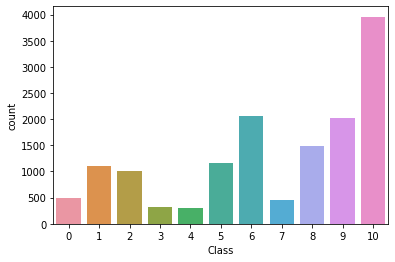

In [7]:
sns.countplot(data= train, x="Class")

<AxesSubplot:>

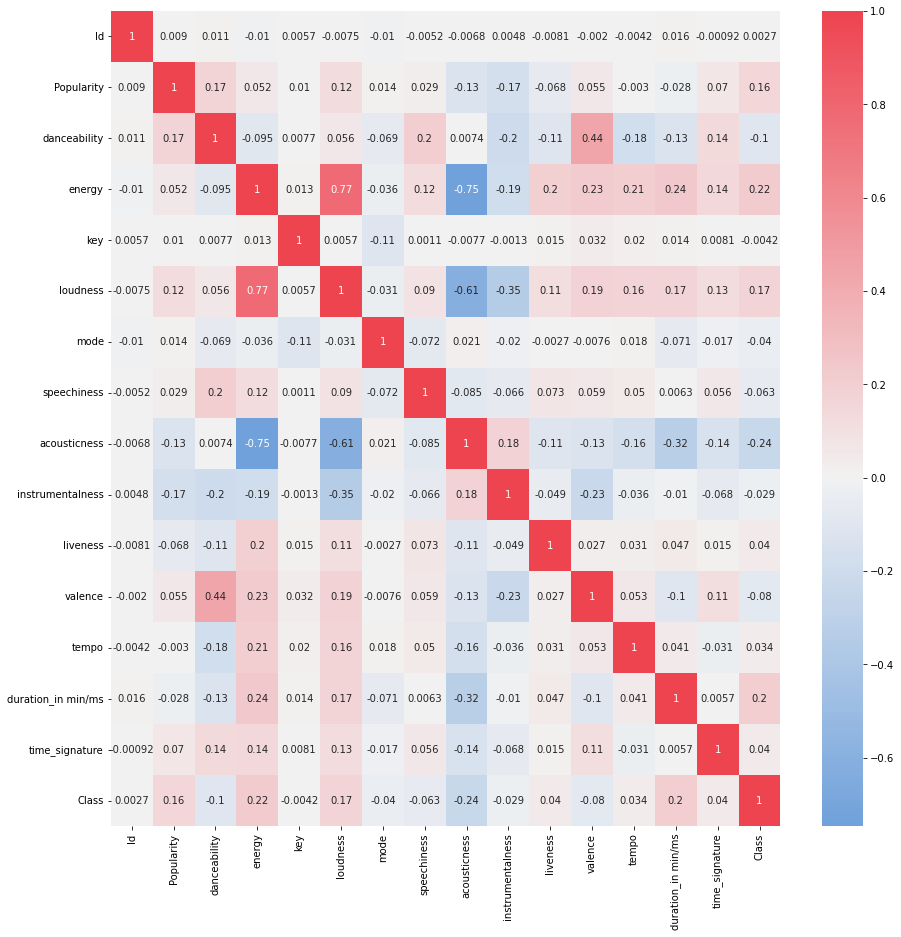

In [8]:
#correlation matrix
corrmat= train.corr()
plt.figure(figsize=(15,15))  

cmap = sns.diverging_palette(250, 10, s=80, l=55, n=9, as_cmap=True)

sns.heatmap(corrmat,annot=True, cmap=cmap, center=0)

<AxesSubplot:>

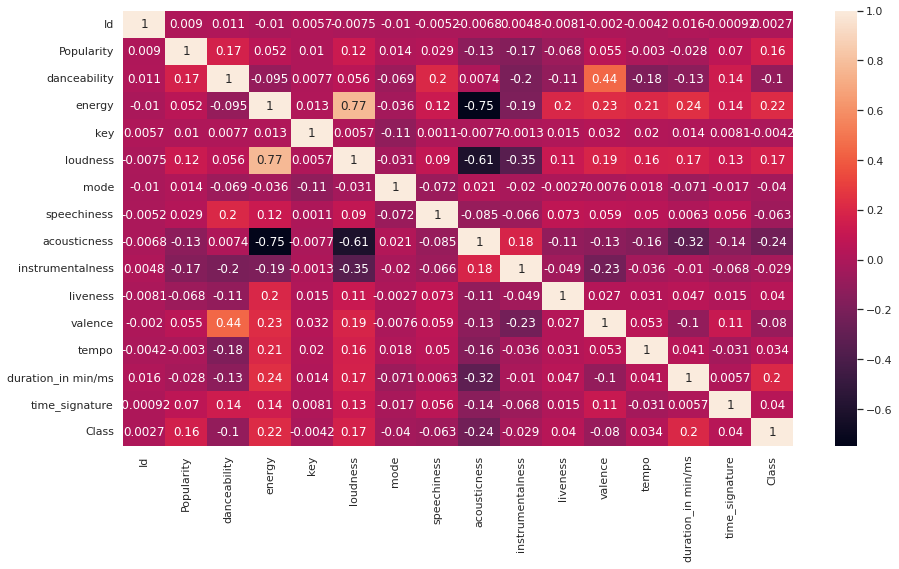

In [9]:
sns.set(rc = {'figure.figsize':(15,8)})
sns.heatmap(train.corr(),annot=True)

### **Drop Unwanted Column's**

In [11]:
train.drop(['Id','Artist Name','Track Name','Class'], axis=1, inplace=True)
test.drop(['Id','Artist Name','Track Name'], axis=1, inplace=True)

def clean_data(df):
    df['Popularity'].fillna(float(df['Popularity'].mean()), inplace=True)
    df['key'].fillna(int(df['key'].mean()), inplace=True)
    df['instrumentalness'].fillna(float(df['instrumentalness'].mean()), inplace=True)
    return df

In [12]:
train = clean_data(train)
test = clean_data(test)

## **Column Density Visualization** 

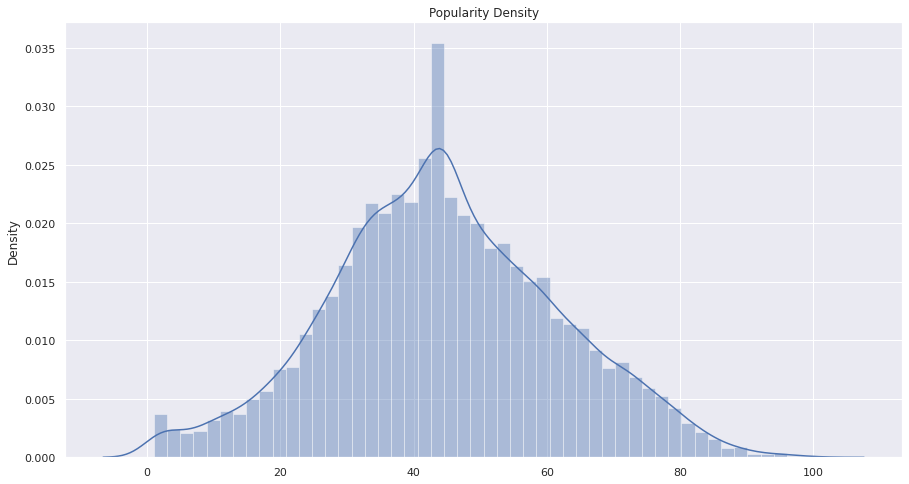

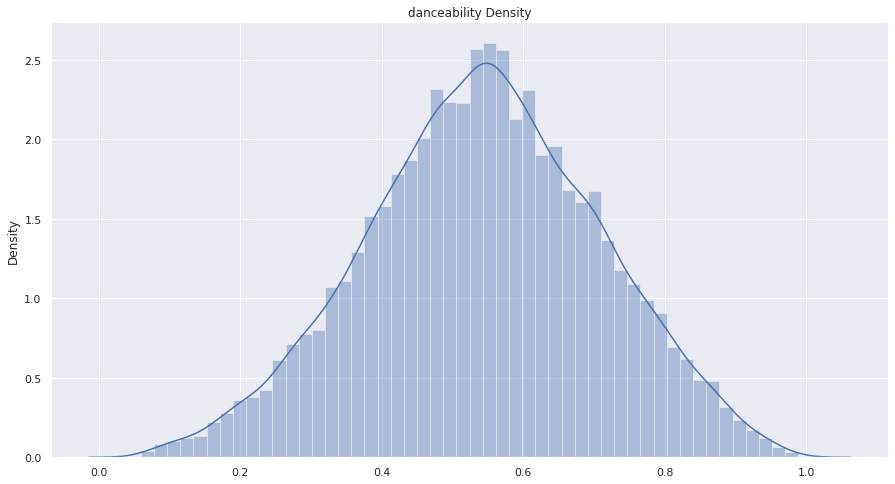

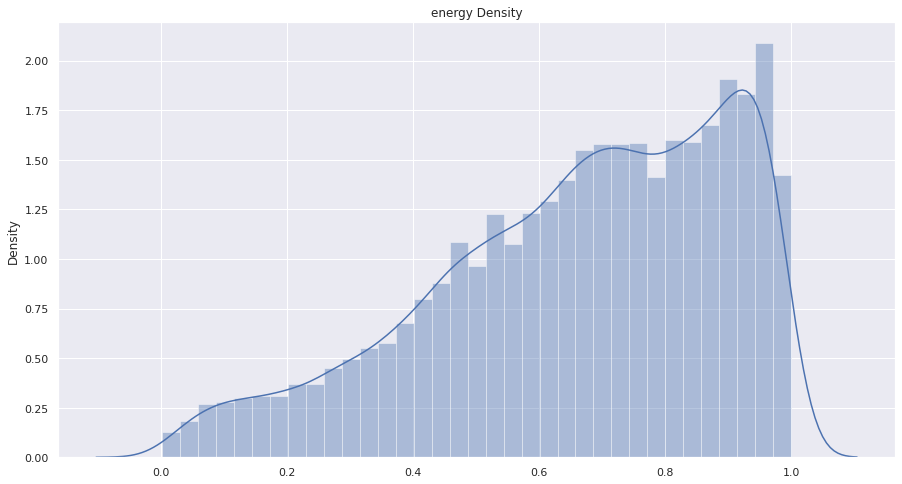

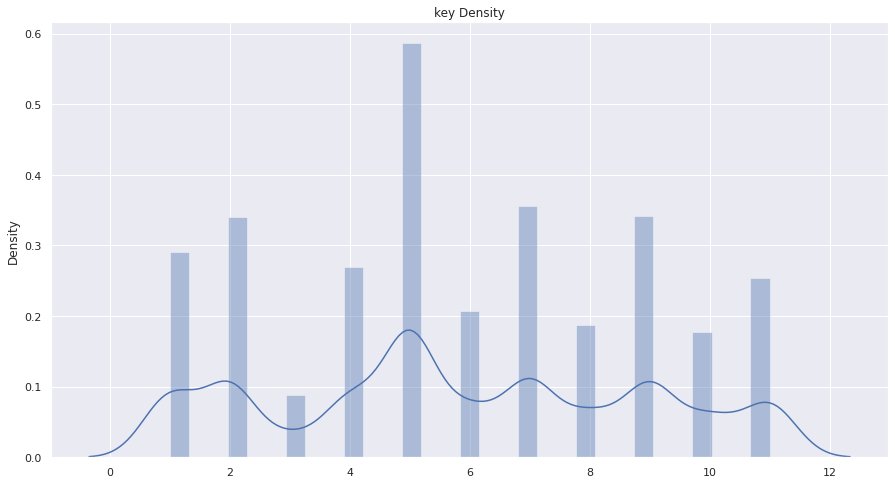

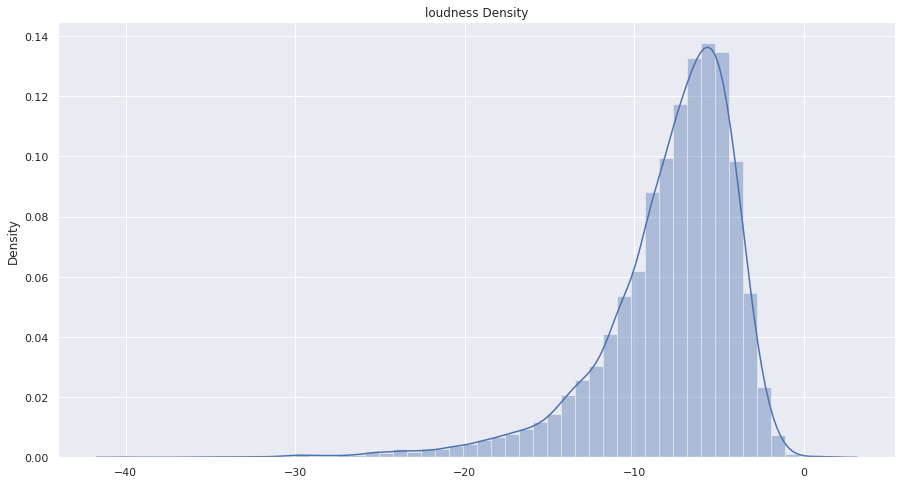

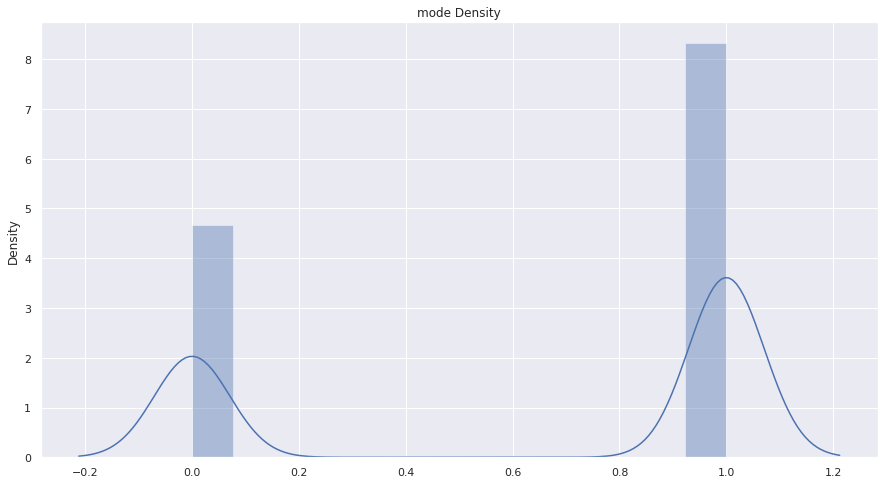

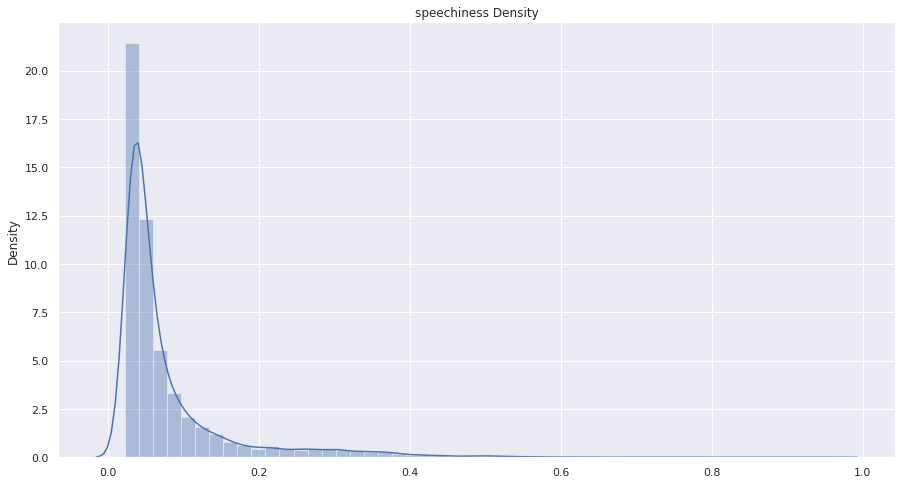

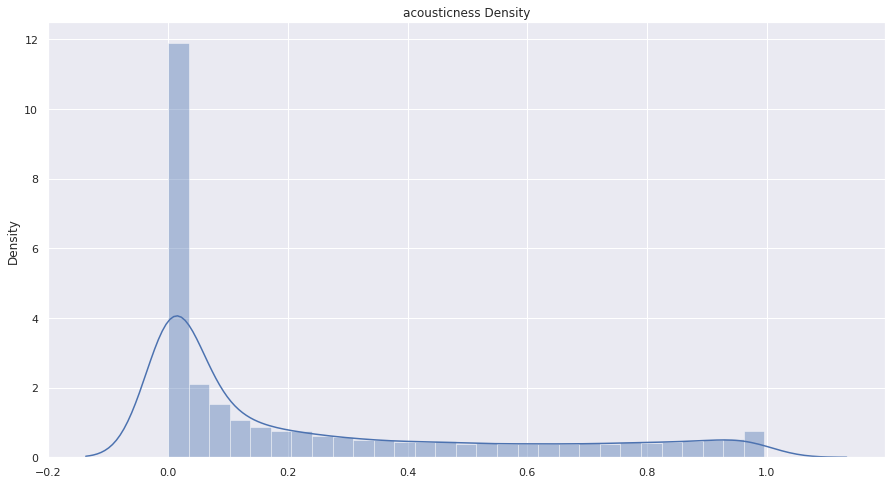

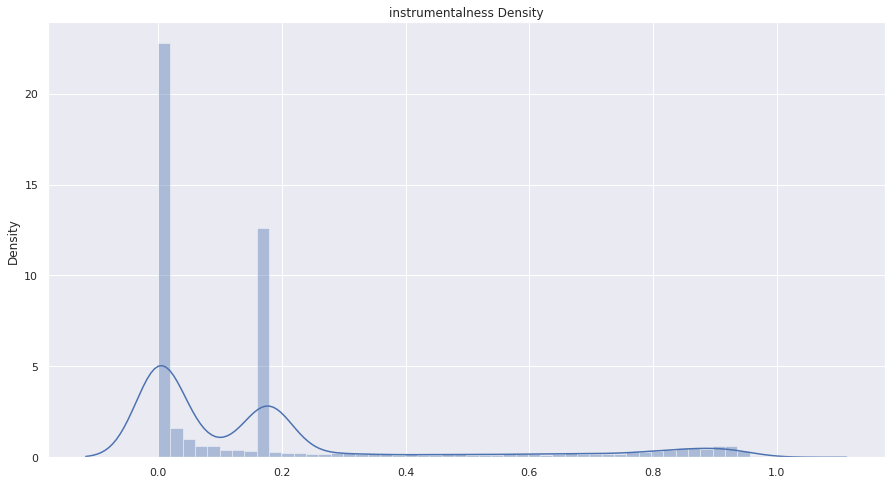

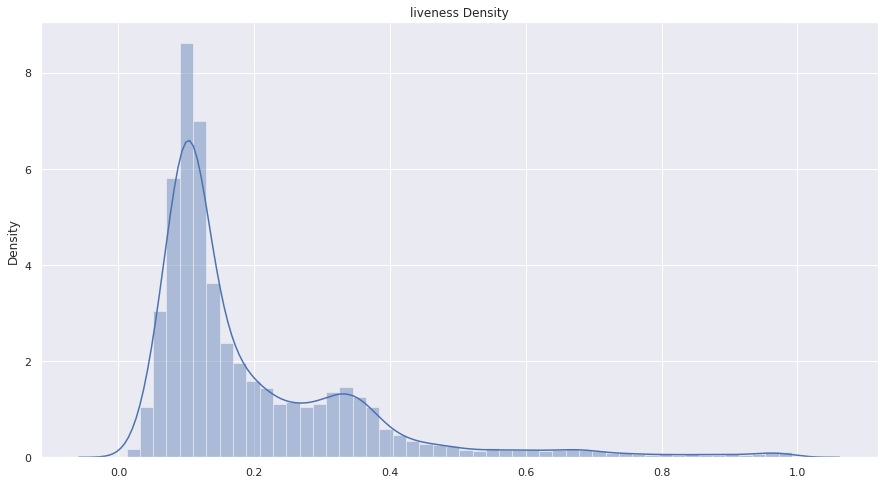

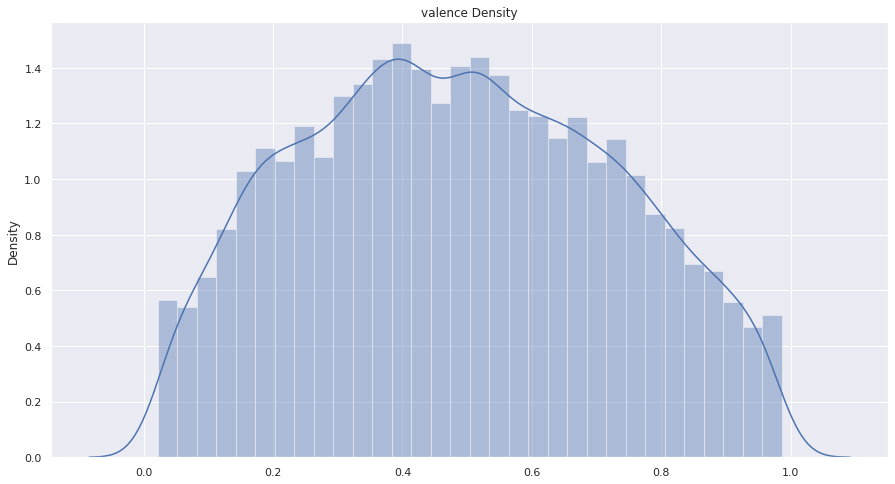

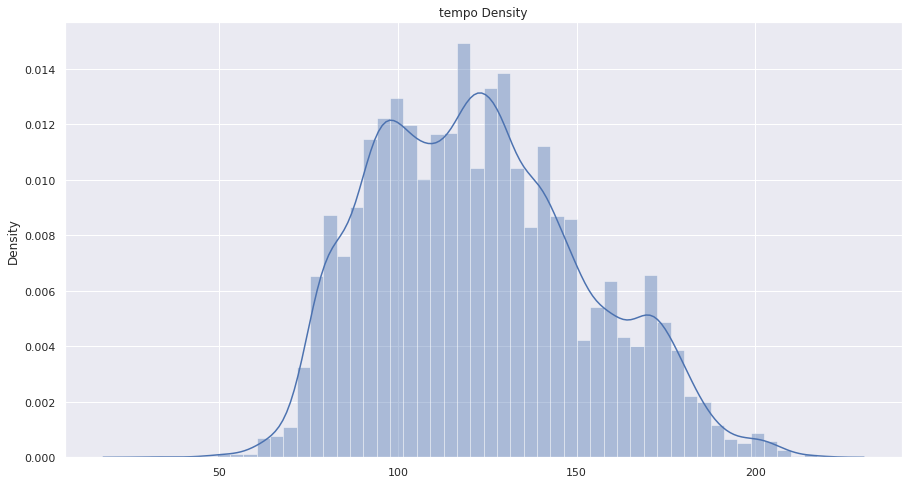

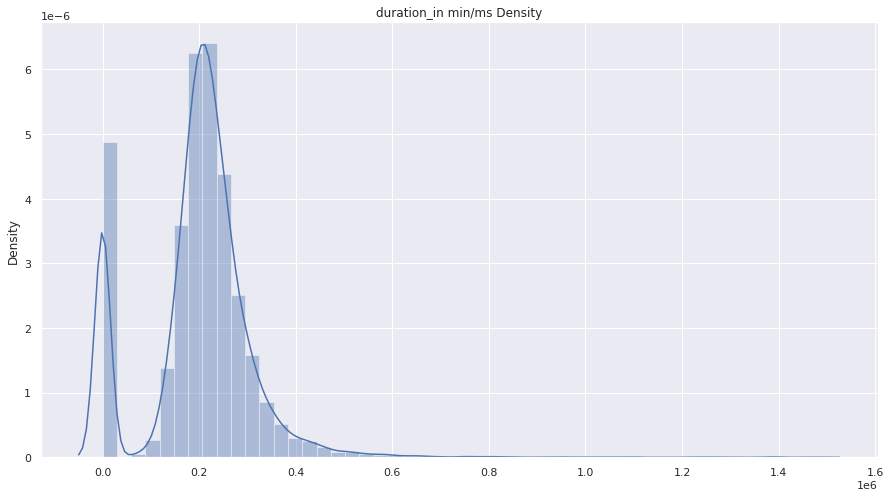

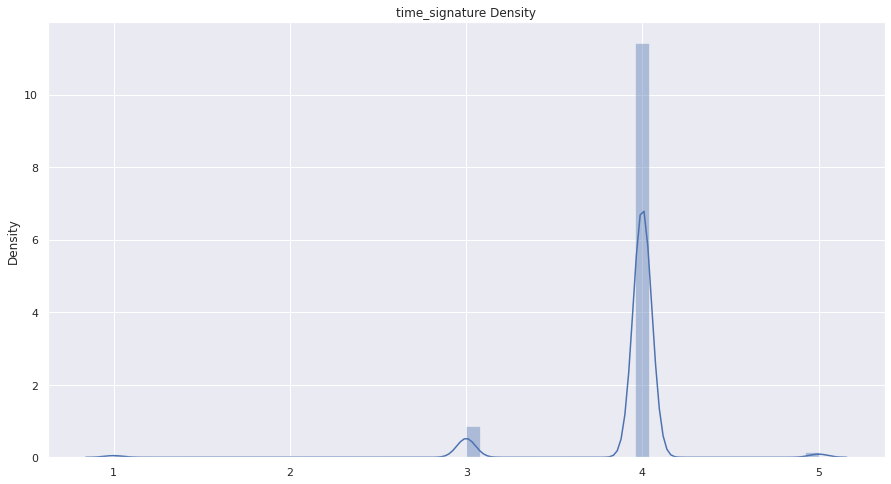

In [13]:
features=train.iloc[0:10000]
for i in features.columns:
    plt.figure()
    sns.distplot(x=train[i]).set(title=i+' Density')

In [14]:
train.isna().sum()

Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
dtype: int64

In [15]:
train.shape, targets.shape, test.shape

((14396, 14), (14396,), (3600, 14))

#### **Scalling the Data**

In [16]:
rb.fit(train)
train = rb.transform(train)
test = rb.transform(test)

# **RandomForestClassifier Model Train**

In [17]:
model = RandomForestClassifier(random_state = 2022, n_jobs = -1, n_estimators = 10000, verbose=1)
model.fit(train, targets)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:   39.2s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:   52.3s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 10000 out of 

RandomForestClassifier(n_estimators=10000, n_jobs=-1, random_state=2022,
                       verbose=1)

### **Model Evaluation**

In [20]:
y_pred_t = model.predict(train)
print("\nACCURACY OF THE MODEL: ", metrics.accuracy_score(targets, y_pred_t))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    1.2s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:    2.8s
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:    3.8s
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:    5.0s
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:    6.4s
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:    7.9s
[Parallel(n_jobs=4)]: Done 6042 tasks      | elapsed:    9.5s
[Parallel(n_jobs=4)]: Done 7192 tasks      | elapsed:   11.3s
[Parallel(n_jobs=4)]: Done 8442 tasks      | elapsed:   13.2s
[Parallel(n_jobs=4)]: Done 9792 tasks      | elapsed:   15.3s



ACCURACY OF THE MODEL:  0.9229647124201167


[Parallel(n_jobs=4)]: Done 10000 out of 10000 | elapsed:   15.6s finished


# **Model Predication**

In [21]:
y_pred = model.predict(test)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:    1.0s
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:    2.4s
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:    3.0s
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:    3.7s
[Parallel(n_jobs=4)]: Done 6042 tasks      | elapsed:    4.5s
[Parallel(n_jobs=4)]: Done 7192 tasks      | elapsed:    5.3s
[Parallel(n_jobs=4)]: Done 8442 tasks      | elapsed:    6.2s
[Parallel(n_jobs=4)]: Done 9792 tasks      | elapsed:    7.2s
[Parallel(n_jobs=4)]: Done 10000 out of 10000 | elapsed:

# **Submission**

In [24]:
submission_file = pd.read_csv("../input/shai-music-genre-classification/sample_submission (2).csv")
submission_file['Class'] = y_pred.round().astype(int)
submission_file.to_csv('submission.csv', index=False)

In [25]:
submission_file

,Id,Class
0,14397,9
1,14398,6
2,14399,9
3,14400,10
4,14401,5
...,...,...
3595,17992,10
3596,17993,5
3597,17994,1
3598,17995,2


## **Predicted Class**

In [26]:
submission_file['Class'].value_counts()

10    1361
9      482
6      435
8      297
5      268
2      217
0      162
1      123
7      108
4       76
3       71
Name: Class, dtype: int64